# University Physics with Modern Physics

<img src="..//pics/cover.png" width=400> 



In [2]:
import setuptools

print("setuptools version:", setuptools.__version__)  # Should be < 70.0.0

import vpython as vp
from astropy import units as u
from astropy import constants as const
import sympy as sp
import numpy as np
from IPython.display import display, Math
import matplotlib.pyplot as plt
import sys
from pathlib import Path

print("All imports succeeded!")

setuptools version: 69.5.1


<IPython.core.display.Javascript object>

All imports succeeded!


In [3]:
# Add root folder to sys.path
sys.path.append(str(Path("..").resolve()))

# Import your helper function directly
from helper_functions import fmt_vec


In [4]:
!python --version

Python 3.12.10


In [5]:
pwd


'c:\\Users\\crodr\\BK_tech\\Physics\\BK_University_Physics_Young_15\\ch02'

# 2 Motion Along a Stright Line
## EXERCISES
### SECTION 2.5 Freely Falling Objects

page 89

#### 2.33

• A juggler throws a bowling pin straight up with an initial speed
of 8.20 m/s. How much time elapses until the bowling pin returns to the
juggler’s hand?

In [ ]:
# --- SymPy Symbols (_sym suffix) ---
v0, v, a, t = sp.symbols("v_0 v a t", real=True, positive=True)

# 1. Formula for way up until stops with v=0
eq1 = sp.Eq(v, v0 + a * t)

# Solve symbolically
t_expr = sp.solve(eq1, t)[0]

# Display equations with LHS
display(Math(rf"t = {sp.latex(t_expr)}"))

<IPython.core.display.Math object>

In [ ]:
# Problem constants with units
v0_qty = 8.20 * (u.m / u.s)
v_qty = 0 * (u.m / u.s)  # stops at max height
g_qty = const.g0
a_qty = -g_qty


# --- 1. Derive callable from SymPy ---
calc_t = sp.lambdify((v, v0, a), t_expr)

# calculation
t_qty = calc_t(v_qty, v0_qty, a_qty)
t_total_qty = 2 * t_qty


print(f"calculated uptime : {t_qty:.2f}")
print(f"calculated total time: {t_total_qty:.2f}")


calculated uptime : 0.84 s
calculated total time: 1.67 s


#### 2.34 

•• You throw a glob of putty straight up toward the ceiling,
which is 3.60 m above the point where the putty leaves your hand. The
initial speed of the putty as it leaves your hand is 9.50 m/s. 

**(a)** What is the speed of the putty just before it strikes the ceiling? 

**(b)** How much time from when it leaves your hand does it take the putty 
to reach the ceiling?

In [ ]:
# Problem constants with units
x_qty = 3.60 * u.m
v0_qty = 9.50 * (u.m / u.s)
g_qty = const.g0
a_qty = -g_qty

# v^2 = v0^2 + 2ax
v_qty = (v0_qty**2 + (2 * a_qty * x_qty)) ** (1 / 2)

# v = v0 + at ==> t = (v - v0) / a
t_qty = (v_qty - v0_qty) / a_qty

# --- print results ---
print(f"Part (a): Speed = {v_qty:.2f} ")
print(f"Part (b): Time = {t_qty:.3f} ")
800701

Part (a): Speed = 4.43 m / s 
Part (b): Time = 0.517 s 


#### 2.35 

•• A tennis ball on Mars, where the acceleration due to gravity
is 0.379g and air resistance is negligible, is hit directly upward
and returns to the same level 8.5 s later. 

**(a)** How high above its original
point did the ball go? 

**(b)** How fast was it moving just after it
was hit?

In [ ]:
# --- SymPy Symbols ---
a, t_top, v0, v = sp.symbols("a t_{top} v_0 v", positive=True)

# time to reach maximun height is t_top = t/2
# at top vertical v = 0, using v = v0 + at

# 1. Formula for way up until stops with v=0
eq1 = sp.Eq(v, v0 + a * t_top)

# Solve symbolically
v0_expr = sp.solve(eq1, v0)[0]

# Display equations with LHS
display(Math(rf"v0 = {sp.latex(v0_expr)}"))

<IPython.core.display.Math object>

In [ ]:
# --- 1. Derive callables from SymPy ---
v0_func = sp.lambdify((a, t_top, v), v0_expr)

# --- 2. Astropy Quantities (_qty suffix) ---
g_qty = const.g0
g_mars_qty = 0.379 * g_qty
a_qty = -g_mars_qty
t_qty = 8.5 * u.s
t_top_qty = t_qty / 2
v_top_qty = 0 * (u.m / u.s)

# --- 3. Calculations ---
v0_qty = v0_func(a_qty, t_top_qty, v_top_qty)
# h = Vo t + 1/2 a t^2
h_max_qty = (v0_qty * t_top_qty) + ((1 / 2) * a_qty * t_top_qty**2)


# --- print results ---
print(f"Part (b): Initial velocity v0 = {v0_qty:.1f}")
print(f"Part (a): Maximun height h_max = {h_max_qty:.2f}")


Part (b): Initial velocity v0 = 15.8 m / s
Part (a): Maximun height h_max = 33.57 m


**(c)** Sketch graphs of the ball’s vertical position, vertical
velocity, and vertical acceleration as functions of time while it’s in
the Martian air.

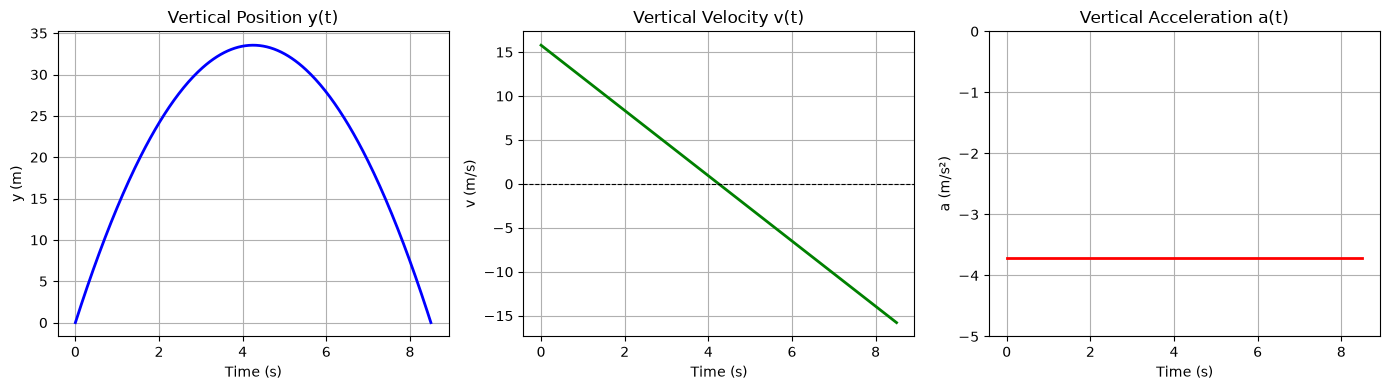

In [ ]:
# Parameters
g_mars = 0.379 * 9.80  # 3.7142 m/s^2
t_tot = 8.5
v0 = (g_mars * t_tot) / 2  # ~15.79 m/s

t = np.linspace(0, t_tot, 300)
y = v0 * t - 0.5 * g_mars * t**2
v = v0 - g_mars * t
a = -g_mars * np.ones_like(t)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Position y(t)
axes[0].plot(t, y, "b-", lw=2)
axes[0].set_title("Vertical Position y(t)")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("y (m)")
axes[0].grid(True)

# Velocity v(t)
axes[1].plot(t, v, "g-", lw=2)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Vertical Velocity v(t)")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("v (m/s)")
axes[1].grid(True)

# Acceleration a(t)
axes[2].plot(t, a, "r-", lw=2)
axes[2].set_title("Vertical Acceleration a(t)")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("a (m/s²)")
axes[2].set_ylim(-5, 0)
axes[2].grid(True)

plt.tight_layout()
plt.show()

#### 2.37 

•• A rock is thrown straight up with an initial speed of 24.0 m/s.
Neglect air resistance. 

**(a)** At t = 1.0 s, what are the directions of the
velocity and acceleration of the rock? Is the speed of the rock increasing
or decreasing? 

**(b)** At t = 3.0 s, what are the directions of the velocity
and acceleration of the rock? Is the speed of the rock increasing or
decreasing?

In [ ]:
# --- SymPy Symbols ---
v0, g, t = sp.symbols("v_0 g t", real=True, positive=True)

# Velocity and acceleration expressions
v_expr = v0 + g * t
a_expr = +g

display(Math(rf"\text{{Velocity function: }} v(t) = {sp.latex(v_expr)}"))
display(Math(rf"\text{{Acceleration: }} a(t) = {sp.latex(a_expr)}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
# --- 1. Derive callables from SymPy ---

calc_v = sp.lambdify((g, t, v0), v_expr)

# --- 2. Astropy Quantities ---
v0_qty = 24.0 * (u.m / u.s)
g_qty = -const.g0

t_a = 1.0 * u.s
t_b = 3.0 * u.s

# --- 3. Calculations ---
v_a = calc_v(g_qty, t_a, v0_qty)
v_b = calc_v(g_qty, t_b, v0_qty)

print(
    f"Part (a) t = 1.0 s: v = {v_a:.1f} | Velocity: UP, Accel: DOWN, Speed: DECREASING"
)
print(
    f"Part (b) t = 3.0 s: v = {v_b:.1f} | Velocity: DOWN, Accel: DOWN, Speed: INCREASING"
)

Part (a) t = 1.0 s: v = 14.2 m / s | Velocity: UP, Accel: DOWN, Speed: DECREASING
Part (b) t = 3.0 s: v = -5.4 m / s | Velocity: DOWN, Accel: DOWN, Speed: INCREASING


#### 2.38 

•• A brick is dropped (zero initial speed) from the roof of a
building. The brick strikes the ground in 1.90 s. You may ignore air
resistance, so the brick is in free fall. 

**(a)** How tall, in meters, is the
building? 

**(b)** What is the magnitude of the brick’s velocity just before it
reaches the ground? 



In [ ]:
# --- SymPy Symbols ---
g, t = sp.symbols("g t", real=True, positive=True)

# 1. Height expression h = 1/2 * g * t^2
h_expr = sp.Rational(1, 2) * g * t**2

# 2. Final velocity magnitude expression |v| = g * t
v_mag_expr = g * t

display(Math(rf"\text{{Building height: }} h = {sp.latex(h_expr)}"))
display(Math(rf"\text{{Impact velocity magnitude: }} |v_y| = {sp.latex(v_mag_expr)}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [72]:
# --- 1. Derive callables from SymPy ---

calc_h = sp.lambdify((g, t), sp.Rational(1, 2) * g * t**2)
calc_v = sp.lambdify((g, t), g * t)

# --- 2. Astropy Quantities ---
g_qty = const.g0
t_qty = 1.90 * u.s

# --- 3. Calculations ---
h_qty = calc_h(g_qty, t_qty)
v_mag_qty = calc_v(g_qty, t_qty)

print(f"Part (a) Height of building: {h_qty.value:.2f} {h_qty.unit}")
print(f"Part (b) Velocity magnitude:  {v_mag_qty.value:.2f} {v_mag_qty.unit}")

Part (a) Height of building: 17.70 m
Part (b) Velocity magnitude:  18.63 m / s


**(c)** Sketch $a_y-t, v_y-t, and y-t$ graphs for the motion
of the brick.

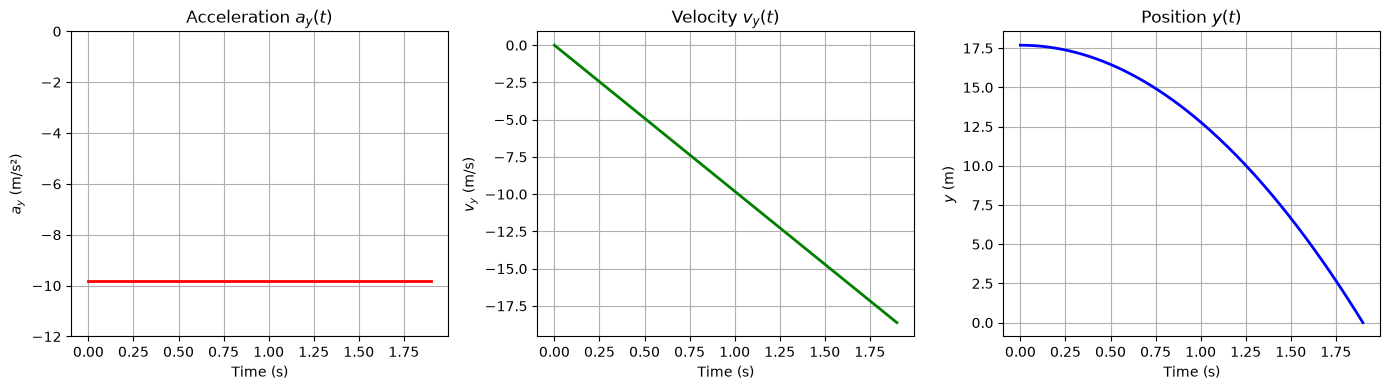

In [ ]:
# Parameters
g = 9.80  # m/s^2
t_final = 1.90  # s
h = 0.5 * g * t_final**2  # ~17.69 m

t = np.linspace(0, t_final, 200)
a_y = -g * np.ones_like(t)
v_y = -g * t
y = h - 0.5 * g * t**2

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Acceleration graph
axes[0].plot(t, a_y, "r-", lw=2)
axes[0].set_title(r"Acceleration $a_y(t)$")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel(r"$a_y$ (m/s²)")
axes[0].set_ylim(-12, 0)
axes[0].grid(True)

# Velocity graph
axes[1].plot(t, v_y, "g-", lw=2)
axes[1].set_title(r"Velocity $v_y(t)$")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel(r"$v_y$ (m/s)")
axes[1].grid(True)

# Position graph
axes[2].plot(t, y, "b-", lw=2)
axes[2].set_title(r"Position $y(t)$")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel(r"$y$ (m)")
axes[2].grid(True)

plt.tight_layout()
plt.show()

2.39 

•• **A Simple Reaction-Time Test**. A meter stick is held vertically
above your hand, with the lower end between your thumb and first
finger. When you see the meter stick released, you grab it with those
two fingers. You can calculate your reaction time from the distance
the meter stick falls, read directly from the point where your fingers
grabbed it. 

**(a)** Derive a relationship for your reaction time in terms of
this measured distance, d. 

**(b)** If the measured distance is 17.6 cm, what
is your reaction time?

In [12]:
d, x, x0, v0, g, t = sp.symbols("d x x_0 v_0 g t", real=True, positive=True)

# 1. Formula for distance
# from the equation: x = x0 + v0 t + 1/2 a t^2 (x0=0, v0=0)  ==> x = 1/2 a t^2
eq_distance = sp.Eq(d, sp.Rational(1, 2) * g * t**2)

# Solve symbolically
t_expr = sp.solve(eq_distance, t)[0]


print("Part (a): reaction time in terms of distance")
# Display equations with LHS
display(Math(rf"t = {sp.latex(t_expr)}"))


Part (a): reaction time in terms of distance


<IPython.core.display.Math object>

In [16]:
# --- Part (b) ---
# --- 1. Derive callables from SymPy ---
calc_t = sp.lambdify((d, g), t_expr)

# --- 2. Astropy Quantities (_qty suffix) ---
g_qty = const.g0
d_qyt = (17.6 * u.cm).to(u.m)

# --- 3. calculation ---
t_qty = calc_t(d_qyt, g_qty)

print(f"Reaction time t =  {t_qty:.3f} equivalent to {t_qty.to(u.ms):.0f}")

Reaction time t =  0.189 s equivalent to 189 ms


#### 2.40 

•• **Touchdown on the Moon.**

page 89

<img src="..//pics/Fig_E2_40.png" width=300> 


A lunar lander is making its descent to
Moon Base I (Fig. E2.40). The lander
descends slowly under the retro-thrust
of its descent engine. The engine is cut
off when the lander is 5.0 m above the
surface and has a downward speed of
0.8 m/s.With the engine off, the lander
is in free fall. What is the speed of the
lander just before it touches the surface?
The acceleration due to gravity
on the moon is 1.6 m/s2.

In [18]:
# --- 1. Astropy Quantities (_qty suffix) ---
y_qty = 5.0 * u.m
v0_qty = 0.8 * (u.m / u.s)
g_moon_qty = 1.6 * (u.m / u.s**2)

# --- 2. calculation ---
# v^2 = v0^2 + 2 g y ==> v = sqrt(v0^2 + 2 g y)
v_qty = (v0_qty**2 + (2 * g_moon_qty * y_qty)) ** (1 / 2)

print(f"Lander speed =  {v_qty:.1f}")

Lander speed =  4.1 m / s


#### 2.41 

•• **Launch Failure.** A 7500 kg
rocket blasts off vertically from
the launch pad with a constant upward acceleration of 2.25 m/s2
and feels no appreciable air resistance. When it has reached a
height of 525 m, its engines suddenly fail; the only force acting
on it is now gravity. 

**(a)** What is the maximum height this
rocket will reach above the launch pad? 

**(b)** How much time will
elapse after engine failure before the rocket comes crashing down
to the launch pad, and how fast will it be moving just before
it crashes? 



In [41]:
# --- SymPy Symbols ---
a1_s, y1_s, g_s, t_ff_s = sp.symbols(
    "a_1 y_1 g t_{free_fall}", real=True, positive=True
)

# 1. Velocity at failure
v1_s = sp.sqrt(2 * a1_s * y1_s)

# 2. Maximum height
y_max_s = y1_s + (v1_s**2) / (2 * g_s)
y_max_simplified = sp.simplify(y_max_s)

# 3. Crash velocity magnitude
v_crash_s = sp.sqrt(2 * g_s * y_max_simplified)

# 4. Quadratic equation for free fall time: 1/2*g*t^2 - v1*t - y1 = 0
eq_t = sp.Eq(sp.Rational(1, 2) * g_s * t_ff_s**2 - v1_s * t_ff_s - y1_s, 0)
t_ff_expr = sp.solve(eq_t, t_ff_s)[0]

display(Math(rf"\text{{Maximum height: }} y_{{max}} = {sp.latex(y_max_simplified)}"))
display(Math(rf"\text{{Crash speed: }} |v_{{crash}}| = {sp.latex(v_crash_s)}"))
display(
    Math(
        rf"\text{{Time after failure: }} t_{{free\_fall}} = {sp.latex(sp.simplify(t_ff_expr))}"
    )
)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [42]:
# --- 1. Derive callables from SymPy ---
a1, y1, g = sp.symbols("a1 y1 g", positive=True)
v1 = sp.sqrt(2 * a1 * y1)
y_max = y1 + a1 * y1 / g
v_crash = sp.sqrt(2 * g * y_max)
t_ff = (v1 + sp.sqrt(v1**2 + 2 * g * y1)) / g

calc_ymax = sp.lambdify((a1, y1, g), y_max)
calc_vcrash = sp.lambdify((a1, y1, g), v_crash)
calc_tff = sp.lambdify((a1, y1, g), t_ff)

# --- 2. Astropy Quantities ---
a1_qty = 2.25 * (u.m / u.s**2)
y1_qty = 525.0 * u.m
g_qty = 9.80 * (u.m / u.s**2)

# --- 3. Calculations ---
ymax_qty = calc_ymax(a1_qty, y1_qty, g_qty)
vcrash_qty = calc_vcrash(a1_qty, y1_qty, g_qty)
tff_qty = calc_tff(a1_qty, y1_qty, g_qty)

print(f"Part (a) Maximum height:     {ymax_qty.value:.2f} {ymax_qty.unit}")
print(f"Part (b) Time after failure: {tff_qty.value:.2f} {tff_qty.unit}")
print(f"Part (b) Crash speed:        {vcrash_qty.value:.2f} {vcrash_qty.unit}")

Part (a) Maximum height:     645.54 m
Part (b) Time after failure: 16.44 s
Part (b) Crash speed:        112.48 m / s


**(c)** Sketch $a_y-t, v_y-t$, and $ y-t$ graphs of the rocket’s
motion from the instant of blast-off to the instant just before it strikes
the launch pad.

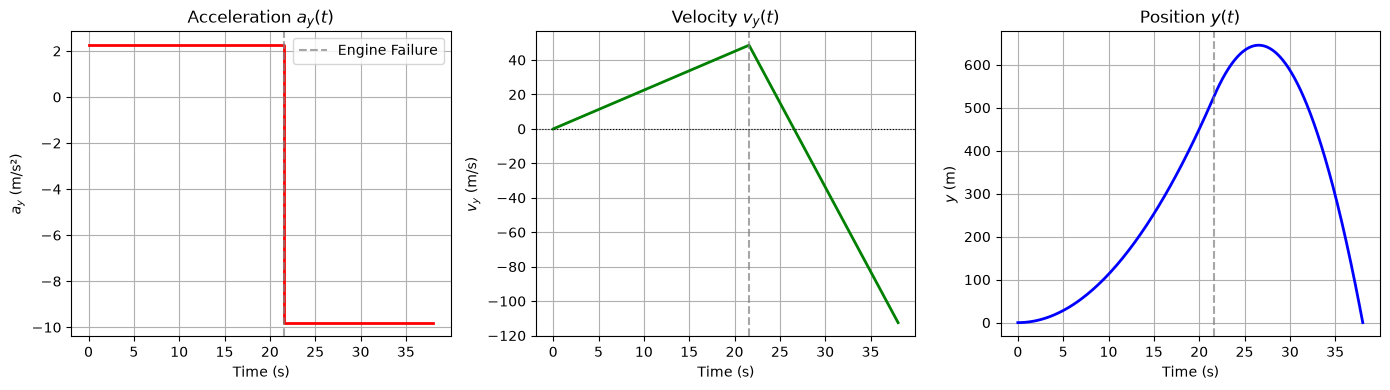

In [43]:
# Constants
a1 = 2.25
y1 = 525.0
g = 9.80

v1 = np.sqrt(2 * a1 * y1)  # ~48.605 m/s
t1 = v1 / a1  # ~21.60 s
t_ff = (v1 + np.sqrt(v1**2 + 2 * g * y1)) / g  # ~16.44 s
t_total = t1 + t_ff

# Time arrays for Phase 1 (ascent) and Phase 2 (free fall)
t_phase1 = np.linspace(0, t1, 100)
t_phase2 = np.linspace(t1, t_total, 200)

# Kinematics Phase 1
y_p1 = 0.5 * a1 * t_phase1**2
v_p1 = a1 * t_phase1
a_p1 = a1 * np.ones_like(t_phase1)

# Kinematics Phase 2
dt = t_phase2 - t1
y_p2 = y1 + v1 * dt - 0.5 * g * dt**2
v_p2 = v1 - g * dt
a_p2 = -g * np.ones_like(t_phase2)

# Concatenate for full plot
t_full = np.concatenate([t_phase1, t_phase2])
y_full = np.concatenate([y_p1, y_p2])
v_full = np.concatenate([v_p1, v_p2])
a_full = np.concatenate([a_p1, a_p2])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Acceleration Graph
axes[0].plot(t_full, a_full, "r-", lw=2)
axes[0].axvline(t1, color="gray", linestyle="--", alpha=0.7, label="Engine Failure")
axes[0].set_title(r"Acceleration $a_y(t)$")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel(r"$a_y$ (m/s²)")
axes[0].grid(True)
axes[0].legend()

# Velocity Graph
axes[1].plot(t_full, v_full, "g-", lw=2)
axes[1].axvline(t1, color="gray", linestyle="--", alpha=0.7)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle=":")
axes[1].set_title(r"Velocity $v_y(t)$")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel(r"$v_y$ (m/s)")
axes[1].grid(True)

# Position Graph
axes[2].plot(t_full, y_full, "b-", lw=2)
axes[2].axvline(t1, color="gray", linestyle="--", alpha=0.7)
axes[2].set_title(r"Position $y(t)$")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel(r"$y$ (m)")
axes[2].grid(True)

plt.tight_layout()
plt.show()

#### 2.42 

page 89

<img src="..//pics/Fig_E2_42.png" width=300> 


•• A hot-air balloonist, rising
vertically with a constant velocity of
magnitude 5.00 m/s, releases a sandbag
at an instant when the balloon is 40.0 m
above the ground (Fig. E2.42). After
the sandbag is released, it is in free fall.

**(a)** Compute the position and velocity
of the sandbag at 0.250 s and
1.00 s after its release.



In [66]:
def pos_y(y0, v0, t, a):
    y = y0 + v0 * t + (1 / 2) * a * t**2
    return y


def vel(v0, a, t):
    v = v0 + a * t
    return v


# --- Given parameters ---
v0_qty = 5.00 * (u.m / u.s)
y0_qty = 40.0 * u.m
a_qty = -const.g0

t1_qty = 0.250 * u.s
t2_qty = 1.00 * u.s

# calculations
y1_qty = pos_y(y0_qty, v0_qty, t1_qty, a_qty)
y2_qty = pos_y(y0_qty, v0_qty, t2_qty, a_qty)

v1_qty = vel(v0_qty, a_qty, t1_qty)
v2_qty = vel(v0_qty, a_qty, t2_qty)


print(f"=== Part (a) ===")
print(f"Position at {t1_qty}: y1 = {y1_qty:.2f}, v1 = {v1_qty:.2f}")
print(f"Position at {t2_qty}: y2 = {y2_qty:.2f}, v2 = {v2_qty:.2f}")


=== Part (a) ===
Position at 0.25 s: y1 = 40.94 m, v1 = 2.55 m / s
Position at 1.0 s: y2 = 40.10 m, v2 = -4.81 m / s


**(b)** How many
seconds after its release does the
bag strike the ground? 

In [51]:
# --- SymPy Symbols ---
y0, t, a = sp.symbols("y_0, t, a", real=True, positive=True)

# from the equation: y = y0 + v0 t + 1/2 a t^2 (y=0, reach the floor)
eq_high = sp.Eq(y, y0 + v0 * t + (1 / 2) * a * t**2)

# Solve symbolically
t_expr = sp.solve(eq_high, t)[0]

# Display equations with LHS
display(Math(rf"t = {sp.latex(t_expr)}"))

<IPython.core.display.Math object>

In [55]:
# --- Derive callables from SymPy ---
calc_t = sp.lambdify((v0, a, y, y0), t_expr)

# --- 2. Astropy Quantities (_qty suffix) ---
y_qty = 0 * u.m  # y=0 is at the ground

# --- 3. calculation ---
t_qty = calc_t(v0_qty, a_qty, y_qty, y0_qty)

print(f"The bag strike the ground at t =  {t_qty:.2f}")

The bag strike the ground at t =  3.41 s


**(c)** With what
magnitude of velocity does it strike
the ground? 

In [58]:
vf_qty = vel(v0_qty, a_qty, t_qty)  # using function define in part (a)
vf_mag_qty = abs(vf_qty)
print(f"Mag. velocity strikes the ground vf={vf_mag_qty:.2f}")


Mag. velocity strikes the ground vf=28.45 m / s


**(d)** What is the greatest
height above the ground that the sandbag
reaches?

In [ ]:
# --- SymPy Symbols ---
y_max, v0, v, a = sp.symbols("y_{max}, v_0, v, a ", real=True, positive=True)

# from the equation: v^2 = v0^2 + 2 a y (when v=0, its at the apex)
eq_vel_sq = sp.Eq(v**2, v0**2 + 2 * a * y_max)

# Solve symbolically
y_max_expr = sp.solve(eq_vel_sq, y_max)[0]

# Display equations with LHS
display(Math(rf"y_{{max}} = {sp.latex(y_max_expr)}"))

<IPython.core.display.Math object>

In [ ]:
# --- Derive callables from SymPy ---
calc_y_max = sp.lambdify((v, v0, a), y_max_expr)

# --- Astropy Quantities (_qty suffix) ---
v_qty = 0  # at the apex

# --- calculation ---
y_max_qty = calc_y_max(v_qty, v0_qty, a_qty)
h_max_qty = y_max_qty + y0_qty

print(f"Bag greatest height h_max =  {h_max_qty:.2f}")

Bag greatest height h_max =  41.27 m


 (e) Sketch $ a_y-t, v_y-t$, and
$y-t$ graphs for the motion.

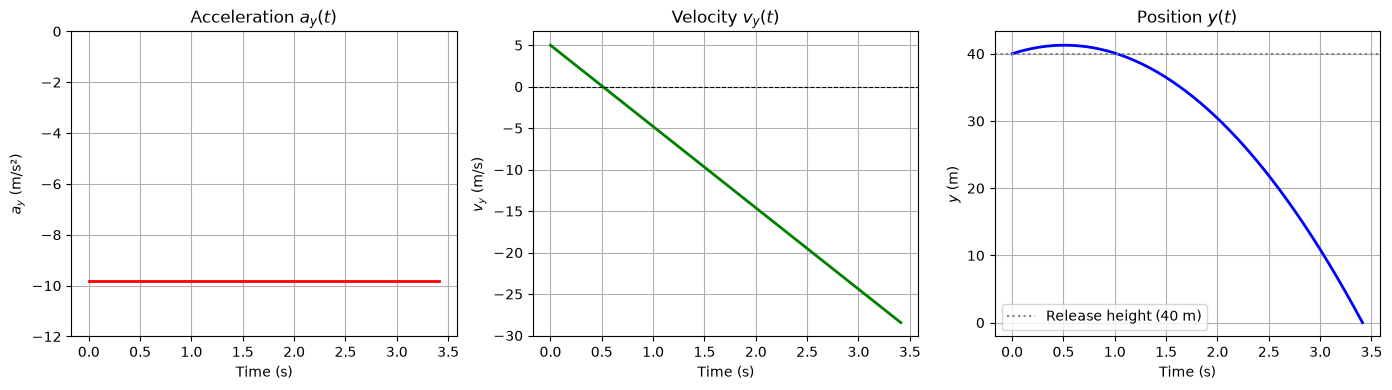

In [67]:
# Parameters
y0 = 40.0
v0 = 5.00
g = 9.80
t_hit = (v0 + np.sqrt(v0**2 + 2 * g * y0)) / g  # ~3.41 s

t = np.linspace(0, t_hit, 300)
a_y = -g * np.ones_like(t)
v_y = v0 - g * t
y = y0 + v0 * t - 0.5 * g * t**2

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Acceleration Graph
axes[0].plot(t, a_y, "r-", lw=2)
axes[0].set_title(r"Acceleration $a_y(t)$")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel(r"$a_y$ (m/s²)")
axes[0].set_ylim(-12, 0)
axes[0].grid(True)

# Velocity Graph
axes[1].plot(t, v_y, "g-", lw=2)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title(r"Velocity $v_y(t)$")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel(r"$v_y$ (m/s)")
axes[1].grid(True)

# Position Graph
axes[2].plot(t, y, "b-", lw=2)
axes[2].axhline(40.0, color="gray", linestyle=":", label="Release height (40 m)")
axes[2].set_title(r"Position $y(t)$")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel(r"$y$ (m)")
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()

#### 2.43 

page 90

• You throw a rock straight up and find that it returns to your
hand 3.60 s after it left your hand. Neglect air resistance. What was the
maximum height above your hand that the rock reached?

In [73]:
t_qty = 3.60 * u.s
t_top_qty = t_qty / 2
a_qty = const.g0

# from the equation: x = x0 + v0 t + 1/2 a t^2 (x0=0, v0=0)  ==> x = 1/2 a t^2
y_max_qty = (1 / 2) * a_qty * t_top_qty**2

print(f"Max height: y_max = {y_max_qty:.1f}")


Max height: y_max = 15.9 m


#### 2.44

An egg is thrown nearly vertically upward from a point near
the cornice of a tall building. The egg just misses the cornice on the way
down and passes a point 30.0 m below its starting point 5.00 s after it
leaves the thrower’s hand. Ignore air resistance. 

**(a)** What is the initial speed of the egg? 

**(b)** How high does it rise above its starting point?

**(c)** What is the magnitude of its velocity at the highest point? 

**(d)** What are the magnitude and direction of its acceleration at the highest point?


In [ ]:
y, v0, g, t = sp.symbols("y v_0 g t", real=True)

# 1. Kinematic equation for position
y_expr = v0 * t + sp.Rational(1, 2) * g * t**2

# 2. Solve for initial velocity
v0_expr = sp.solve(sp.Eq(y_expr, y), v0)[0]

# 3. Maximum height above start (v = 0)
ymax_expr = v0**2 / (2 * g)


display(Math(rf"\text{{Initial velocity: }} v_0 = {sp.latex(v0_expr)}"))
display(Math(rf"\text{{Max height: }} y_{{max}} = {sp.latex(sp.simplify(ymax_expr))}"))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [9]:
calc_v0 = sp.lambdify((y, g, t), v0_expr)
calc_ymax = sp.lambdify((v0, g), ymax_expr)

# --- 2. Values with units ---
y_qty = -30.0 * u.m
g_qty = -const.g0
t_qty = 5.00 * u.s

# --- 3. Compute ---
v0_qty = calc_v0(y_qty, g_qty, t_qty)
ymax_qty = calc_ymax(v0_qty, g_qty)

print(f"Part (a) Initial speed: {v0_qty:.2f}")
print(f"Part (b) Max height:   {ymax_qty:.2f}")
print(f"Part (c) Velocity at the highest point:  (v = 0 m / s) by definition")
print(f"Part (d) Acceleration at the highest point:  (g = {g_qty:.2f} ) downward")


Part (a) Initial speed: 18.52 m / s
Part (b) Max height:   -17.48 m
Part (c) Velocity at the highest point:  (v = 0 m / s) by definition
Part (d) Acceleration at the highest point:  (g = -9.81 m / s2 ) downward



**(e)** Sketch $a_y-t, v_y-t$, and $y-t$ graphs for the motion of the egg.

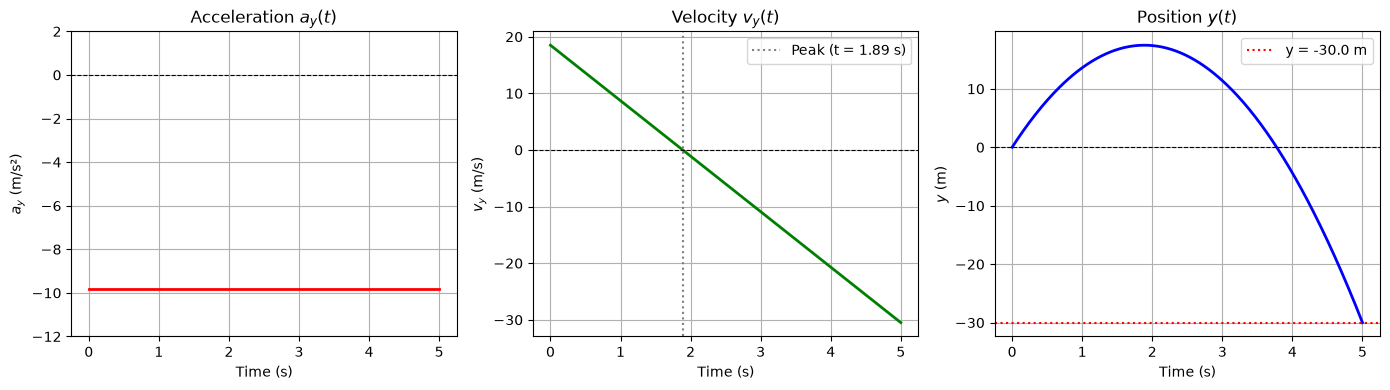

In [ ]:
v0 = 18.5
g = 9.80
t_total = 5.00

t = np.linspace(0, t_total, 300)
a_y = -g * np.ones_like(t)
v_y = v0 - g * t
y = v0 * t - 0.5 * g * t**2

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Acceleration Graph
axes[0].plot(t, a_y, "r-", lw=2)
axes[0].axhline(0, color="black", lw=0.8, ls="--")
axes[0].set_title(r"Acceleration $a_y(t)$")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel(r"$a_y$ (m/s²)")
axes[0].set_ylim(-12, 2)
axes[0].grid(True)

# Velocity Graph
axes[1].plot(t, v_y, "g-", lw=2)
axes[1].axhline(0, color="black", lw=0.8, ls="--")
axes[1].axvline(v0 / g, color="gray", ls=":", label=f"Peak (t = {v0 / g:.2f} s)")
axes[1].set_title(r"Velocity $v_y(t)$")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel(r"$v_y$ (m/s)")
axes[1].grid(True)
axes[1].legend()

# Position Graph
axes[2].plot(t, y, "b-", lw=2)
axes[2].axhline(0, color="black", lw=0.8, ls="--")
axes[2].axhline(-30.0, color="red", ls=":", label="y = -30.0 m")
axes[2].set_title(r"Position $y(t)$")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel(r"$y$ (m)")
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()

#### 2.45 

page 90

•• A 15 kg rock is dropped from rest on the earth and reaches the
ground in 1.75 s. When it is dropped from the same height on Saturn’s
satellite Enceladus, the rock reaches the ground in 18.6 s. What is the
acceleration due to gravity on Enceladus?

In [ ]:
y, v0, g_earth, g_encelado, t_earth, t_encelado = sp.symbols(
    "y, v0, g_{earth}, g_{encelado}, t_{earth}, t_{encelado}", real=True
)

# 1. Kinematic equation for position
# y = v0 * t + sp.Rational(1, 2) * g * t**2 (v0=0) ==> y = sp.Rational(1, 2) * g * t**2
y_earth_expr = sp.Rational(1, 2) * g_earth * t_earth**2
y_encelado_expr = sp.Rational(1, 2) * g_encelado * t_encelado**2

# 2. Solve for g_encelado
g_expr = sp.solve(sp.Eq(y_earth_expr, y_encelado_expr), g_encelado)[0]

display(Math(rf" {sp.latex(g_encelado)} = {sp.latex(g_expr)}"))


<IPython.core.display.Math object>

In [ ]:
calc_gencelado = sp.lambdify((g_earth, t_earth, t_encelado), g_expr)

# --- 2. Values with units ---
g_earth_qty = const.g0
t_earth_qty = 1.75 * u.s
t_encelado_qty = 18.6 * u.s

# --- 3. Compute ---
g_encelado_qty = calc_gencelado(g_earth_qty, t_earth_qty, t_encelado_qty)

print(f"Gravity in Encelado: {g_encelado_qty:.3g}")  # .3g ==> 3 significant figures


Gravity in Encelado: 0.0868 m / s2


#### 2.46 

• A large boulder is ejected vertically upward from a volcano with
an initial speed of 40.0 m/s. Ignore air resistance. 

**(a)** At what time after
being ejected is the boulder moving at 20.0 m/s upward? 



In [ ]:
v, v0, a, t = sp.symbols("v, v0, a, t", real=True)

# 1. Kinematic equation for velocity
v_expr = v0 + (a * t)

# 1. Formula for time
# from the equation: v = v0 + a t
eq_vel = sp.Eq(v, v0 + a * t)

# Solve symbolically
t_expr = sp.solve(eq_vel, t)[0]

# Display equations with LHS
display(Math(rf"t = {sp.latex(t_expr)}"))


<IPython.core.display.Math object>

In [ ]:
# --- Part (a) ---
# --- 1. Derive callables from SymPy ---
calc_t = sp.lambdify((v, v0, a), t_expr)

# --- 2. Astropy Quantities (_qty suffix) ---
a_qty = -const.g0
v0_qty = 40.0 * (u.m / u.s)
v1_qty = 20.0 * (u.m / u.s)

# --- 3. calculation ---
t1_qty = calc_t(v1_qty, v0_qty, a_qty)

print(f"The boulder is moving at {v1_qty} at time t1 =  {t1_qty:.3g}")

The boulder is moving at 20.0 m / s at time t1 =  2.04 s


**(b)** At what time is it moving at 20.0 m/s downward?

In [ ]:
# --- Part (b) ---

# --- 2. Astropy Quantities (_qty suffix) ---
v2_qty = -20.0 * (u.m / u.s)  # downward along y-axis

# --- 3. calculation ---
t2_qty = calc_t(v2_qty, v0_qty, a_qty)

print(f"The boulder is moving at {v2_qty} at time t2 =  {t2_qty:.3g}")

The boulder is moving at -20.0 m / s at time t2 =  6.12 s


**(c)** When is the displacement of the boulder from its initial position zero?

In [ ]:
d = sp.symbols("d", real=True)

# 1. Formula for displacement
# from the equation: y = v0 t + 1/2 a t^2
eq_displacement = sp.Eq(0, v0 * t + sp.Rational(1, 2) * a * t**2)

# Solve symbolically
d_expr = sp.solve(eq_displacement, t)[1]


# Display equations with LHS
display(Math(rf"t = {sp.latex(d_expr)}"))


<IPython.core.display.Math object>

In [ ]:
# --- Part (c) ---
# --- 1. Derive callables from SymPy ---
calc_t_dis = sp.lambdify((v0, a), d_expr)

# --- 3. calculation ---
t3_qty = calc_t_dis(v0_qty, a_qty)

print(f"The boulder displacement is zero at time t0 = 0 s and t3 = {t3_qty:.3g}")

The boulder displacement is zer0 at time t0 = 0 s and t3 = 8.16 s


 (d) When is the velocity of the
boulder zero?

In [ ]:
# --- 2. Astropy Quantities (_qty suffix) ---
v4_qty = 0.0 * (u.m / u.s)

# --- 3. calculation ---
t4_qty = calc_t(v4_qty, v0_qty, a_qty)

print(f"The boulder is moving at {v4_qty} at time t4 =  {t4_qty:.3g}")


print(
    "The boulder velocity is zero at the apex (maximum height) and when has crahed with the floor "
)

The boulder is moving at 0.0 m / s at time t4 =  4.08 s
The boulder velocity is zero at the apex (maximum height) and when has crahed with the floor 


 **(e)** What are the magnitude and direction of the acceleration
while the boulder is 

* (i) moving upward? 

* (ii) Moving downward? 

* (iii) At the highest point?

In [ ]:
print(
    f"The magnitude of the acceleration is constant in all points: {abs(a_qty):.2f} and the direction is downward."
)

The magnitude of the acceleration is constant in all points: 9.81 m / s2 and the direction is downward.


 **(f)**  Sketch $a_y-t, v_y-t$, and $y-t$ graphs for the motion.

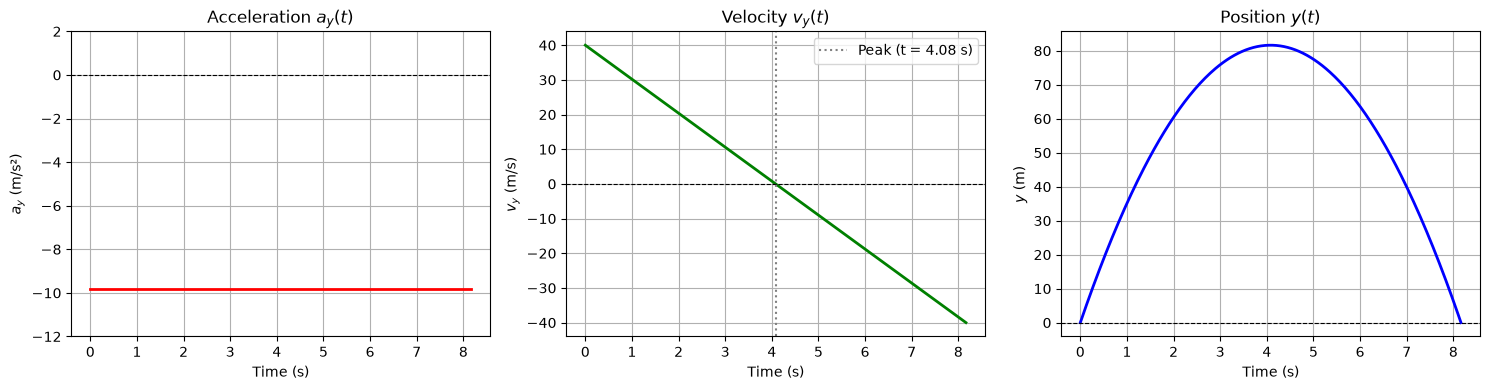

In [ ]:
v0 = 40.0
g = 9.80
t_total = 2 * v0 / g  # 8.16 s

t = np.linspace(0, t_total, 300)
a_y = -g * np.ones_like(t)
v_y = v0 - g * t
y = v0 * t - 0.5 * g * t**2

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Acceleration Graph
axes[0].plot(t, a_y, "r-", lw=2)
axes[0].axhline(0, color="black", lw=0.8, ls="--")
axes[0].set_title(r"Acceleration $a_y(t)$")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel(r"$a_y$ (m/s²)")
axes[0].set_ylim(-12, 2)
axes[0].grid(True)

# Velocity Graph
axes[1].plot(t, v_y, "g-", lw=2)
axes[1].axhline(0, color="black", lw=0.8, ls="--")
axes[1].axvline(v0 / g, color="gray", ls=":", label=f"Peak (t = {v0 / g:.2f} s)")
axes[1].set_title(r"Velocity $v_y(t)$")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel(r"$v_y$ (m/s)")
axes[1].grid(True)
axes[1].legend()

# Position Graph
axes[2].plot(t, y, "b-", lw=2)
axes[2].axhline(0, color="black", lw=0.8, ls="--")
axes[2].set_title(r"Position $y(t)$")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel(r"$y$ (m)")
axes[2].grid(True)

plt.tight_layout()
plt.show()

#### 2.47 

•• You throw a small rock straight up from the edge of a bridge that
crosses a river. The rock passes you on its way down, 6.00 s after it was
thrown. What is the speed of the rock just before it reaches the water 28.0 m
below the point where the rock left your hand? Ignore air resistance.

In [ ]:
t_qty = 6.00 * u.s
t_top_qty = t_qty / 2
a_qty = const.g0
h_bridge_qty = 28 * u.m

# We think a free fall from the apex, t = 1/2
# from the equation: x = x0 + v0 t + 1/2 a t^2 (x0=0, v=0)  ==> x = 1/2 a t^2
y_max_qty = (1 / 2) * a_qty * t_top_qty**2

h_total_qty = y_max_qty + h_bridge_qty
# Considering a free fall from the apex, v = sqrt(2gh)
v_qty = (2 * a_qty * h_total_qty) ** (1 / 2)
print(f"Max height over the bridge: y_max = {y_max_qty:.1f}")
print(f"Rock speed reaching the water: {v_qty:.1f}")


Max height over the bridge: y_max = 44.1 m
Rock speed reaching the water: 37.6 m / s
